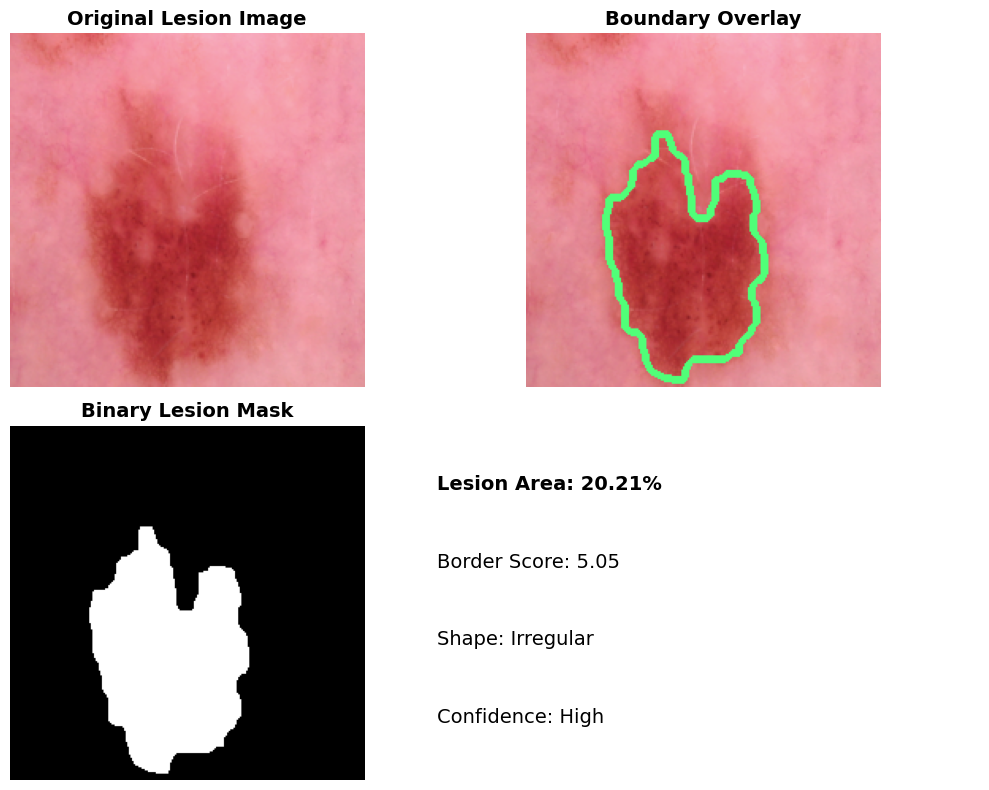

Saved: Figure_4_4_Segmentation_Output.png


In [1]:
import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = "sample_lesion.jpg"
IMG_SIZE = (224,224)

# load
img = Image.open(IMAGE_PATH).convert("RGB").resize(IMG_SIZE)
img_np = np.array(img)

# blur
blur = cv2.GaussianBlur(img_np, (7,7), 0)

# kmeans
data = blur.reshape((-1,3)).astype(np.float32)

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    20,
    1.0
)

K = 3

_, labels, centers = cv2.kmeans(
    data,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

centers = np.uint8(centers)
segmented = centers[labels.flatten()].reshape(img_np.shape)

gray = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)

cluster_vals = [
    np.mean(gray[labels.reshape(224,224)==i])
    for i in range(K)
]

lesion_cluster = int(np.argmin(cluster_vals))

mask = (
    labels.reshape(224,224)==lesion_cluster
).astype(np.uint8)*255

kernel = np.ones((7,7), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = img_np.copy()

area_percent = 0
border_score = 0
shape = "Unknown"
confidence = "Low"

if contours:
    best = max(contours, key=cv2.contourArea)

    cv2.drawContours(
        overlay,
        [best],
        -1,
        (80,255,120),
        3
    )

    area = cv2.contourArea(best)
    total = 224*224
    area_percent = round(area/total*100,2)

    perimeter = cv2.arcLength(best, True)

    circularity = (
        4*np.pi*area
    )/(perimeter*perimeter + 1e-6)

    border_score = round((1-circularity)*10,2)

    shape = (
        "Irregular"
        if border_score > 3
        else "Regular"
    )

    confidence = (
        "High"
        if area > 1500
        else "Medium"
    )

# ==========================
# PLOT
# ==========================
fig, ax = plt.subplots(
    2,
    2,
    figsize=(11,8)
)

ax[0,0].imshow(img_np)
ax[0,0].set_title(
    "Original Lesion Image",
    fontsize=14,
    fontweight="bold"
)

ax[0,1].imshow(overlay)
ax[0,1].set_title(
    "Boundary Overlay",
    fontsize=14,
    fontweight="bold"
)

ax[1,0].imshow(mask, cmap="gray")
ax[1,0].set_title(
    "Binary Lesion Mask",
    fontsize=14,
    fontweight="bold"
)

ax[1,1].axis("off")
ax[1,1].text(
    0.02,
    0.82,
    f"Lesion Area: {area_percent:.2f}%",
    fontsize=14,
    fontweight="bold"
)

ax[1,1].text(
    0.02,
    0.60,
    f"Border Score: {border_score:.2f}",
    fontsize=14
)

ax[1,1].text(
    0.02,
    0.38,
    f"Shape: {shape}",
    fontsize=14
)

ax[1,1].text(
    0.02,
    0.16,
    f"Confidence: {confidence}",
    fontsize=14
)

for row in ax:
    for a in row:
        a.axis("off")

plt.tight_layout()

plt.savefig(
    "Figure_4_4_Segmentation_Output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Figure_4_4_Segmentation_Output.png")